# Credit Portfolio EDA

Exploratory analysis of the synthetic Credit Intelligence AI portfolio. All data is synthetic - see `DATA_CARD.md`.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

customers = pd.read_parquet('../data/raw/customer_portfolio.parquet')
print(customers.shape)
customers.head()

(100000, 31)


,customer_id,origination_date,observation_date,age_band,monthly_income,employment_tenure_months,declared_expenses,existing_debt,number_of_open_accounts,credit_utilization,...,account_tenure_months,number_of_recent_credit_inquiries,previous_default_flag,behavioral_score,financial_stability_index,transaction_volatility,balance_trend,utilization_trend,delinquency_trend,target_default_90d
0,CUST_000001,2021-09-30,2023-03-31,25-34,2607.40,90.0,1407.55,888.00,7,0.0484,...,19,0,0,98.77,0.8244,0.1552,0.0843,-0.1142,-0.1071,0
1,CUST_000002,2022-10-31,2024-11-30,45-54,2698.63,17.3,1200.72,1530.10,3,0.8768,...,26,2,0,4.92,0.0000,0.5166,0.0848,0.0227,0.1274,0
2,CUST_000003,2023-04-30,2024-07-31,35-44,6239.37,41.3,4068.74,1768.52,0,0.8094,...,16,1,1,46.64,0.4698,0.2980,-0.0865,0.1154,-0.0113,0
3,CUST_000004,2023-11-30,2024-01-31,65+,4178.18,8.5,1502.69,469.21,4,0.4420,...,3,0,0,72.27,1.0000,0.2172,-0.0219,-0.0422,0.1014,0
4,CUST_000005,2023-04-30,2023-12-31,65+,9906.51,79.0,5677.04,2737.46,11,0.1252,...,9,0,0,95.69,0.6896,0.1068,-0.1513,0.1169,-0.0074,0


## 1. Target Distribution

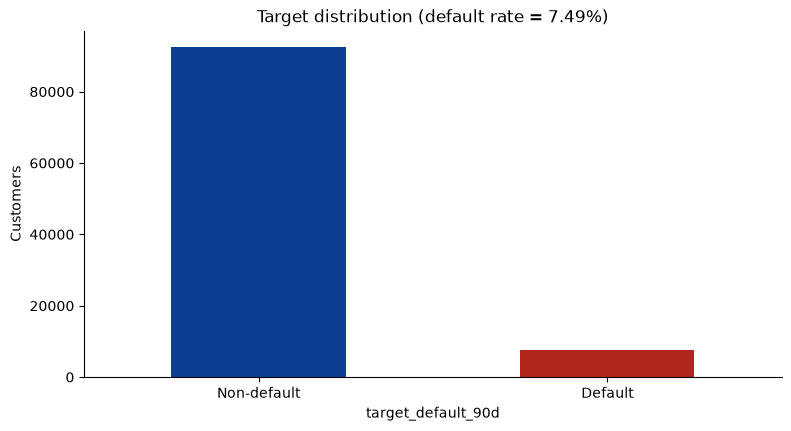

Overall default rate: 7.49%


In [2]:
rate = customers['target_default_90d'].mean()
fig, ax = plt.subplots()
customers['target_default_90d'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color=['#0B3D91', '#B3261E'], title=f'Target distribution (default rate = {rate:.2%})'
)
ax.set_xticklabels(['Non-default', 'Default'], rotation=0)
ax.set_ylabel('Customers')
plt.show()
print(f'Overall default rate: {rate:.2%}')

**Business interpretation.** The portfolio's observed 90-day default rate is in the single-to-low-double digits, consistent with a realistic unsecured consumer credit book (real portfolios of this type are typically strongly imbalanced toward non-default). Any model evaluation on this dataset must therefore avoid accuracy as the primary metric.

## 2. Temporal Analysis

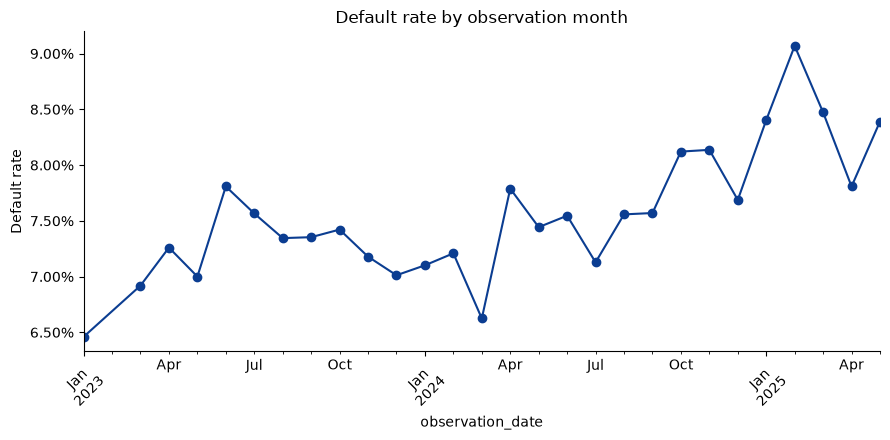

In [3]:
monthly = customers.groupby(customers['observation_date'].dt.to_period('M'))['target_default_90d'].mean()
fig, ax = plt.subplots()
monthly.plot(ax=ax, marker='o', color='#0B3D91', title='Default rate by observation month')
ax.set_ylabel('Default rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Business interpretation.** The synthetic generator injects a slow upward drift in the underlying latent risk factor over calendar time, so later observation months should show a mildly higher default rate on average, alongside normal sampling noise. This is the basis for the portfolio's deterioration narrative used later in the monitoring and vintage analyses (see `docs/PORTFOLIO_STORY.md`).

## 3. Income Distribution

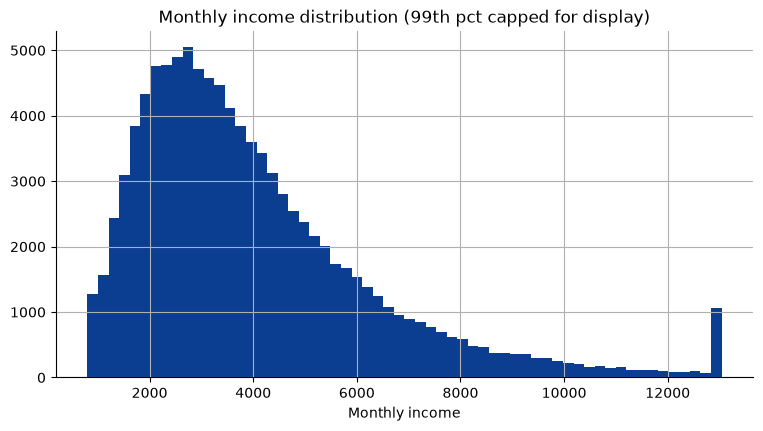

count    100000.000000
mean       4064.331073
std        2605.446937
min         800.000000
25%        2385.715000
50%        3461.565000
75%        5029.817500
max       85093.499988
Name: monthly_income, dtype: float64

In [4]:
fig, ax = plt.subplots()
customers['monthly_income'].clip(upper=customers['monthly_income'].quantile(0.99)).hist(
    bins=60, ax=ax, color='#0B3D91'
)
ax.set_title('Monthly income distribution (99th pct capped for display)')
ax.set_xlabel('Monthly income')
plt.show()
customers['monthly_income'].describe()

**Business interpretation.** Income follows a right-skewed, log-normal-like distribution typical of retail income data, with a long tail of higher earners.

## 4. Debt-to-Income (DTI)

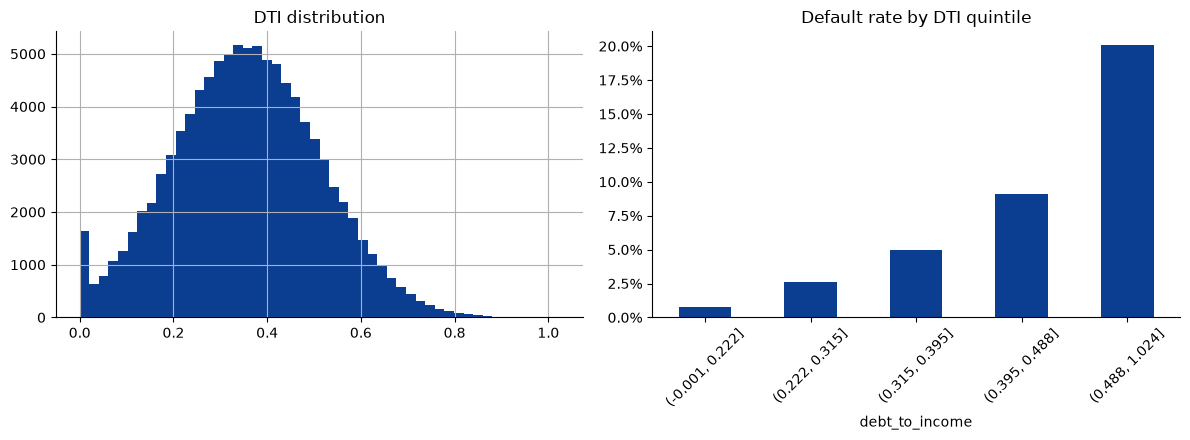

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
customers['debt_to_income'].clip(upper=2).hist(bins=50, ax=axes[0], color='#0B3D91')
axes[0].set_title('DTI distribution')

dti_q = pd.qcut(customers['debt_to_income'], 5, duplicates='drop')
customers.groupby(dti_q, observed=True)['target_default_90d'].mean().plot(
    kind='bar', ax=axes[1], color='#0B3D91', title='Default rate by DTI quintile'
)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Business interpretation.** Default rate rises monotonically and steeply with DTI quintile, confirming DTI as one of the strongest engineered risk drivers - consistent with the model's SHAP global importance ranking (see notebook 04 and `MODEL_CARD.md`).

## 5. Credit Utilization

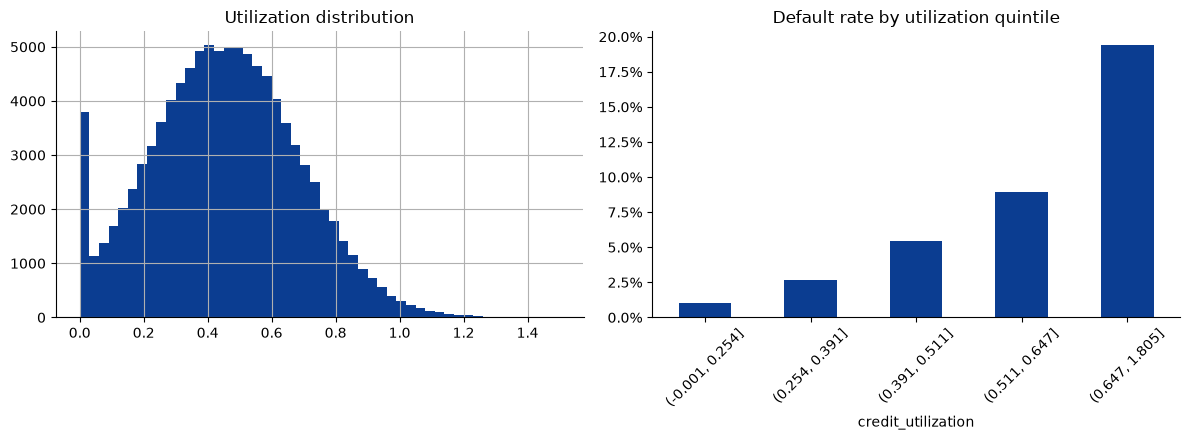

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
customers['credit_utilization'].clip(upper=1.5).hist(bins=50, ax=axes[0], color='#0B3D91')
axes[0].set_title('Utilization distribution')

util_q = pd.qcut(customers['credit_utilization'], 5, duplicates='drop')
customers.groupby(util_q, observed=True)['target_default_90d'].mean().plot(
    kind='bar', ax=axes[1], color='#0B3D91', title='Default rate by utilization quintile'
)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Business interpretation.** Utilization shows the same monotonic pattern as DTI - customers using a larger share of their available credit default substantially more often, matching real-world scorecard experience.

## 6. Late Payments and Delinquency History

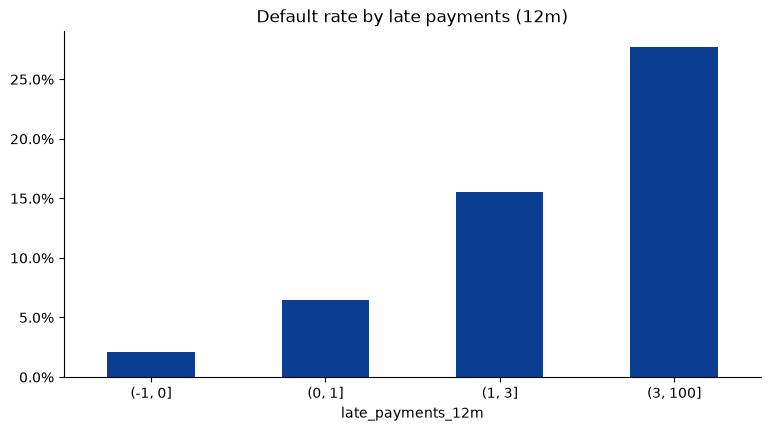

In [7]:
fig, ax = plt.subplots()
bins = [-1, 0, 1, 3, 100]
late_bucket = pd.cut(customers['late_payments_12m'], bins=bins)
customers.groupby(late_bucket, observed=True)['target_default_90d'].mean().plot(
    kind='bar', ax=ax, color='#0B3D91', title='Default rate by late payments (12m)'
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.show()

**Business interpretation.** Prior delinquency is, as expected, one of the most predictive signals available - default rate increases sharply once a customer has any late payment history in the trailing 12 months.

## 7. Behavioral Indicators

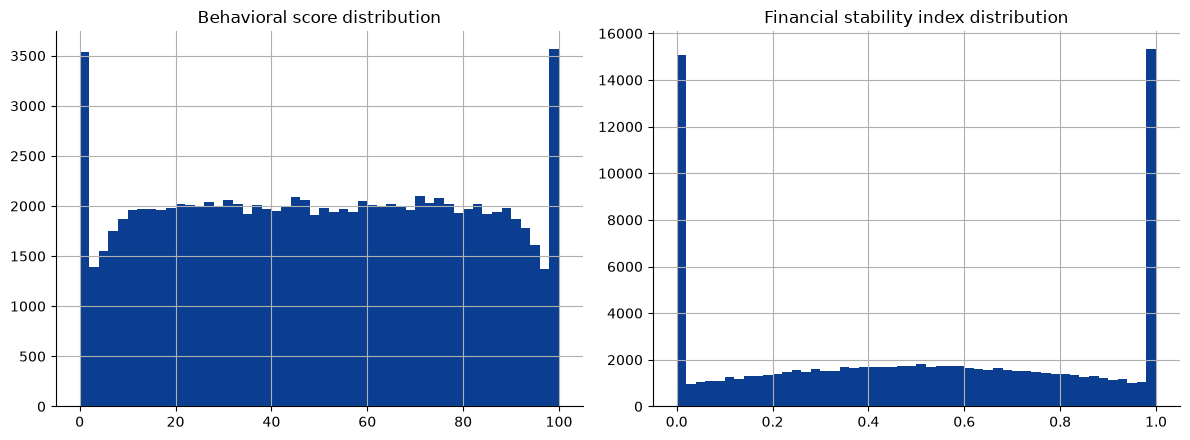

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
customers['behavioral_score'].hist(bins=50, ax=axes[0], color='#0B3D91')
axes[0].set_title('Behavioral score distribution')
customers['financial_stability_index'].hist(bins=50, ax=axes[1], color='#0B3D91')
axes[1].set_title('Financial stability index distribution')
plt.tight_layout()
plt.show()

**Business interpretation.** Both composite behavioral indicators are roughly bell-shaped and behave as intended: lower behavioral score and lower financial stability both correlate with higher observed default rate (confirmed via SHAP in notebook 04).

## 8. Correlations

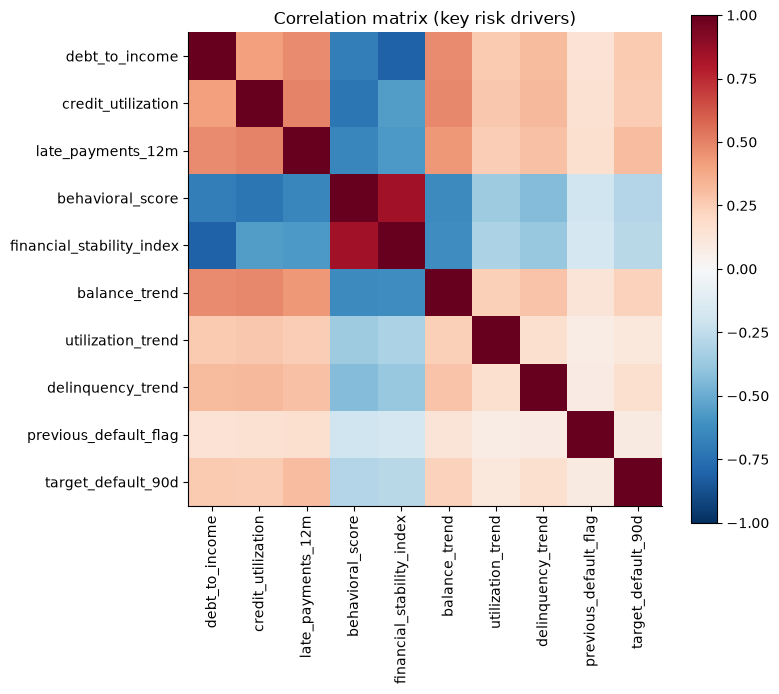

In [9]:
numeric_cols = [
    'debt_to_income', 'credit_utilization', 'late_payments_12m', 'behavioral_score',
    'financial_stability_index', 'balance_trend', 'utilization_trend',
    'delinquency_trend', 'previous_default_flag', 'target_default_90d',
]
corr = customers[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
ax.set_yticks(range(len(numeric_cols)), numeric_cols)
fig.colorbar(im)
ax.set_title('Correlation matrix (key risk drivers)')
plt.tight_layout()
plt.show()

**Business interpretation.** Moderate multicollinearity exists between DTI, utilization, and the trend features, by design (see `DATA_CARD.md`) - this mirrors real bureau/behavioral data, where indebtedness measures naturally correlate.

## 9. Segmentation: Age Band and Payment History

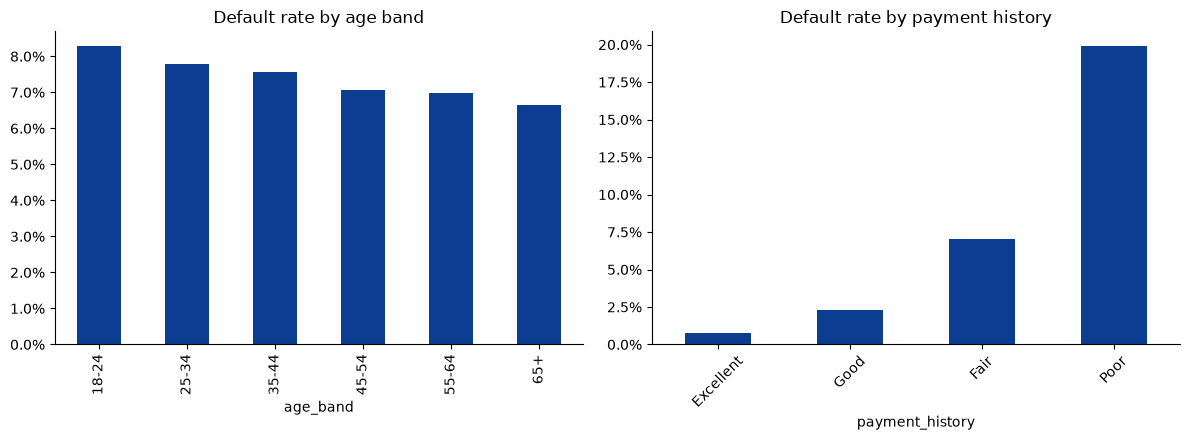

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
customers.groupby('age_band', observed=True)['target_default_90d'].mean().plot(
    kind='bar', ax=axes[0], color='#0B3D91', title='Default rate by age band'
)
customers.groupby('payment_history', observed=True)['target_default_90d'].mean().sort_values().plot(
    kind='bar', ax=axes[1], color='#0B3D91', title='Default rate by payment history'
)
for a in axes:
    a.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Business interpretation.** Younger age bands show mildly higher default rates in this synthetic generator (reflecting a common, if imperfect, industry pattern), and `payment_history` is almost perfectly rank-ordered with observed default, as expected since it is derived from the same latent behavior score.

## 10. Missing Values

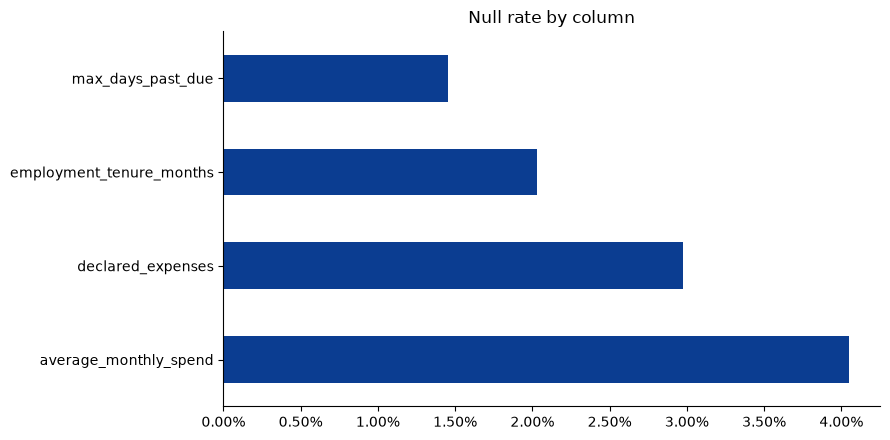

average_monthly_spend       0.04048
declared_expenses           0.02972
employment_tenure_months    0.02032
max_days_past_due           0.01457
dtype: float64

In [11]:
missing = customers.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
fig, ax = plt.subplots()
missing.plot(kind='barh', ax=ax, color='#0B3D91', title='Null rate by column')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()
missing

**Business interpretation.** A handful of fields carry 1.5-4% missingness, injected deliberately to mirror real-world data quality issues (self-reported expenses/spend, employment tenure). The modeling pipeline imputes these at fit time (`src/models/train.py`), never before the temporal split.

## 11. Outliers

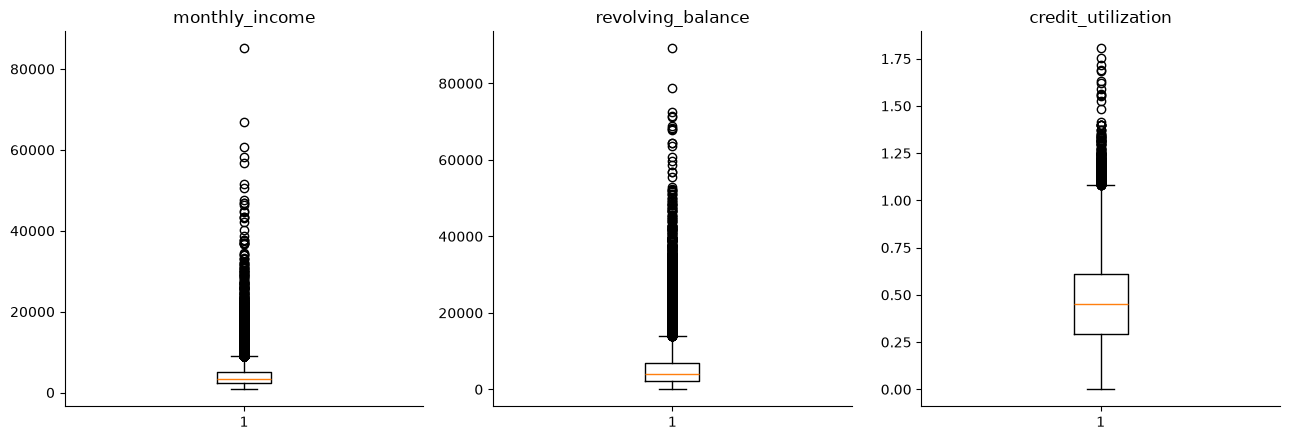

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, col in zip(axes, ['monthly_income', 'revolving_balance', 'credit_utilization']):
    axes_data = customers[col].dropna()
    ax.boxplot(axes_data, orientation='vertical')
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Business interpretation.** A small share of rows contain deliberately injected outliers (e.g. income/balance spikes, over-100% utilization from over-limit spend) - visible as points beyond the boxplot whiskers - to make the modeling problem realistic rather than artificially clean.

## 12. Deterioration Trend Signals

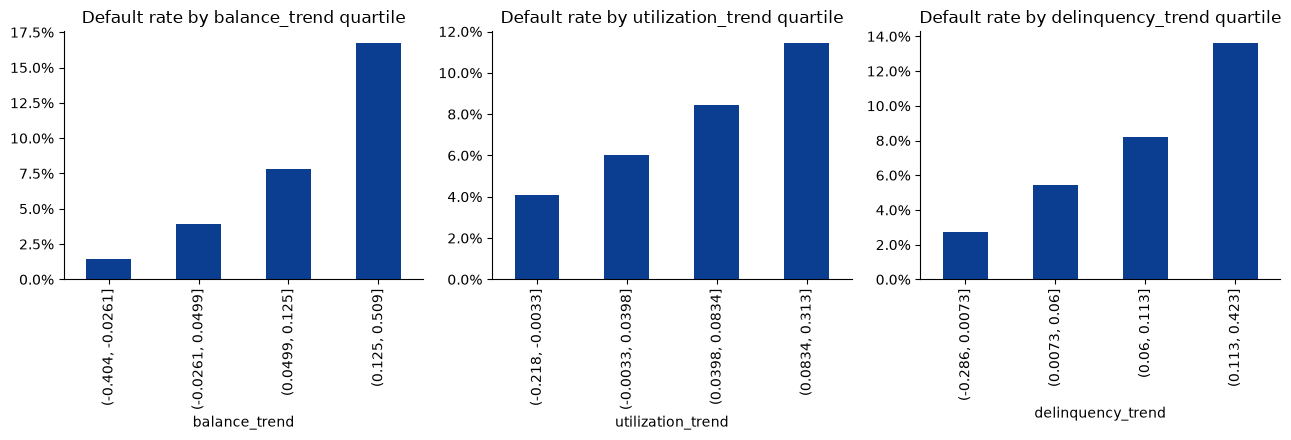

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, col in zip(axes, ['balance_trend', 'utilization_trend', 'delinquency_trend']):
    trend_q = pd.qcut(customers[col], 4, duplicates='drop')
    customers.groupby(trend_q, observed=True)['target_default_90d'].mean().plot(
        kind='bar', ax=ax, color='#0B3D91', title=f'Default rate by {col} quartile'
    )
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

**Business interpretation.** All three directional trend signals show the expected pattern: customers whose balance, utilization, or delinquency severity is trending upward default more often than those trending flat or down. These trends are combined into the `behavioral_deterioration_index` engineered feature (see `FEATURE_DICTIONARY.md`).

## Summary

The synthetic portfolio exhibits the statistical relationships a real credit dataset would show - monotonic risk gradients across DTI, utilization, delinquency history and trend signals - while retaining realistic noise, missingness and outliers. This makes it suitable for demonstrating a genuine modeling and monitoring pipeline rather than a toy, trivially-separable classification problem.